### 01 - Data Exploration

Understand the baseline data and weekly progress before implementing surrogate models.

*Last updated with data through Week 6. The summary and classifications at the end reflect what we knew at that point — some conclusions were later revised once the surrogate model started producing results (notably F4 which broke into positive territory in W5, and F5 which jumped massively in W6).*

This notebook covers:
1. Loading and inspecting baseline data for all 8 functions
2. Analyzing output distributions and identifying noise vs structure
3. Tracking weekly optimization progress
4. Key insights that informed our strategy evolution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Project paths
PROJECT_ROOT = Path('..').resolve()
BASELINE_DIR = PROJECT_ROOT / 'data' / 'baseline'
WEEKLY_DIR = PROJECT_ROOT / 'data' / 'weekly'

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/sethu/work/ml-learning/Capstone-related/bayesian-bbo-capstone


### 1. Function Dimensions

Each function has a different input dimensionality:

In [2]:
FUNCTION_DIMENSIONS = {
    1: 2,
    2: 2,
    3: 3,
    4: 4,
    5: 4,
    6: 5,
    7: 6,
    8: 8
}

print("Function Dimensionality:")
for fid, dim in FUNCTION_DIMENSIONS.items():
    print(f"  Function {fid}: {dim}D")

Function Dimensionality:
  Function 1: 2D
  Function 2: 2D
  Function 3: 3D
  Function 4: 4D
  Function 5: 4D
  Function 6: 5D
  Function 7: 6D
  Function 8: 8D


### 2. Load Baseline Data

Load the initial sample data provided for each function.

In [3]:
def load_baseline(fid):
    """Load baseline data for a specific function."""
    path = BASELINE_DIR / f'function_{fid}_baseline.csv'
    return pd.read_csv(path)

# Load all baseline data
baseline_data = {fid: load_baseline(fid) for fid in range(1, 9)}

# Display summary
print("Baseline Data Summary:")
print("-" * 50)
for fid, df in baseline_data.items():
    print(f"Function {fid}: {len(df)} samples, {df.shape[1]-1} features")

Baseline Data Summary:
--------------------------------------------------
Function 1: 10 samples, 2 features
Function 2: 10 samples, 2 features
Function 3: 15 samples, 3 features
Function 4: 30 samples, 4 features
Function 5: 20 samples, 4 features
Function 6: 20 samples, 5 features
Function 7: 30 samples, 6 features
Function 8: 40 samples, 8 features


### 3. Output Distribution Analysis

Understanding the range and distribution of outputs helps identify:
- **Structured functions**: Clear patterns, wide output range
- **Noisy functions**: Random-looking, extreme values, or flat responses

In [4]:
# Compute statistics for each function
stats = []
for fid, df in baseline_data.items():
    y = df['y']
    stats.append({
        'Function': fid,
        'Min': y.min(),
        'Max': y.max(),
        'Mean': y.mean(),
        'Std': y.std(),
        'Range': y.max() - y.min()
    })

stats_df = pd.DataFrame(stats)
print("Output Statistics per Function:")
print(stats_df.to_string(index=False))

Output Statistics per Function:
 Function        Min           Max       Mean        Std       Range
        1  -0.003606  7.710875e-16  -0.000361   0.001140    0.003606
        2  -0.065624  6.112052e-01   0.230674   0.237555    0.676829
        3  -0.398926 -3.483531e-02  -0.107167   0.087170    0.364090
        4 -32.625660 -4.025542e+00 -17.238587   7.137959   28.600118
        5   0.112940  1.088860e+03 151.271876 251.955640 1088.746680
        6  -2.571170 -7.142650e-01  -1.495390   0.460664    1.856905
        7   0.002701  1.364968e+00   0.219607   0.307294    1.362267
        8   5.592193  9.598482e+00   7.815274   0.958966    4.006289


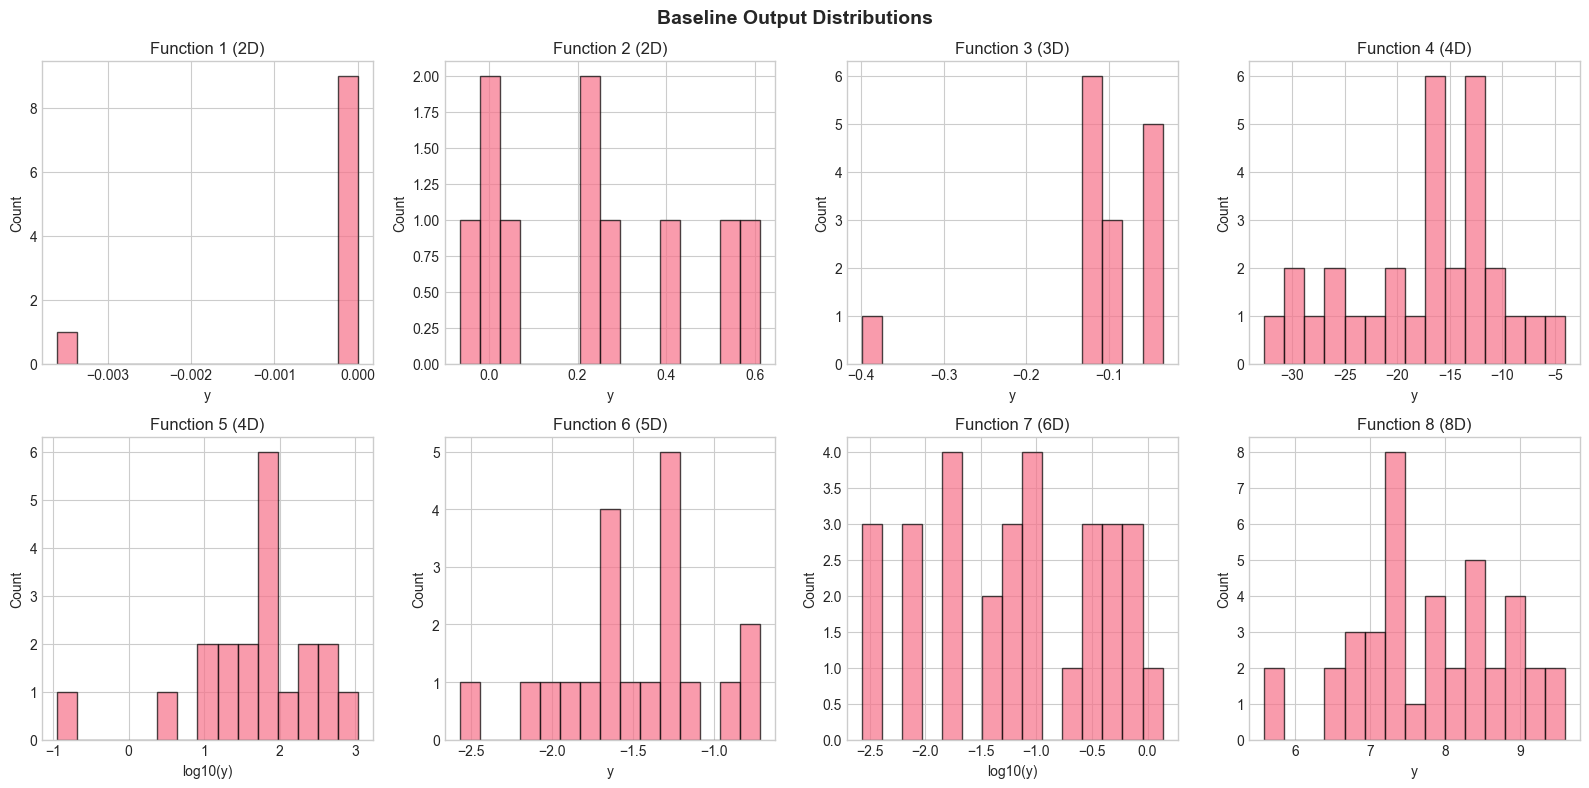

In [5]:
# Visualize output distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (fid, df) in enumerate(baseline_data.items()):
    ax = axes[idx]
    y = df['y']
    
    # Use log scale for functions with extreme ranges
    if y.min() > 0 and (y.max() / y.min()) > 100:
        ax.hist(np.log10(y + 1e-300), bins=15, edgecolor='black', alpha=0.7)
        ax.set_xlabel('log10(y)')
    else:
        ax.hist(y, bins=15, edgecolor='black', alpha=0.7)
        ax.set_xlabel('y')
    
    ax.set_title(f'Function {fid} ({FUNCTION_DIMENSIONS[fid]}D)')
    ax.set_ylabel('Count')

plt.suptitle('Baseline Output Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Function Behavior Classification

Based on baseline analysis, we can classify functions:

In [6]:
# Classify functions based on observed behavior
classification = {
    1: {'type': 'Extremely Noisy', 'strategy': 'UCB', 'notes': 'Values near 10^-79 to 10^-291'},
    2: {'type': 'Structured', 'strategy': 'EI', 'notes': 'Moderate positive values, learnable'},
    3: {'type': 'Flat/Noisy', 'strategy': 'UCB', 'notes': 'Consistently negative, little variation'},
    4: {'type': 'Negative Structured', 'strategy': 'UCB', 'notes': 'Consistently negative outputs'},
    5: {'type': 'Strongly Structured', 'strategy': 'EI', 'notes': 'Wide range (0 to 1088), clear patterns'},
    6: {'type': 'Noisy Negative', 'strategy': 'UCB', 'notes': 'Negative values, some variation'},
    7: {'type': 'Low Signal', 'strategy': 'UCB', 'notes': 'Small positive values'},
    8: {'type': 'Moderate', 'strategy': 'UCB', 'notes': 'Higher dimensional, moderate values'}
}

class_df = pd.DataFrame([
    {'Function': fid, **info} for fid, info in classification.items()
])
print("Function Classification:")
print(class_df.to_string(index=False))

Function Classification:
 Function                type strategy                                   notes
        1     Extremely Noisy      UCB           Values near 10^-79 to 10^-291
        2          Structured       EI     Moderate positive values, learnable
        3          Flat/Noisy      UCB Consistently negative, little variation
        4 Negative Structured      UCB           Consistently negative outputs
        5 Strongly Structured       EI  Wide range (0 to 1088), clear patterns
        6      Noisy Negative      UCB         Negative values, some variation
        7          Low Signal      UCB                   Small positive values
        8            Moderate      UCB     Higher dimensional, moderate values


### 5. Weekly Progress Tracking

Load results from each week to track optimization progress.

In [7]:
def load_weekly_data(week):
    """Load weekly results."""
    path = WEEKLY_DIR / f'week_{week:02d}.csv'
    if path.exists():
        return pd.read_csv(path)
    return None

# Load all weekly data
weekly_data = {}
for week in range(1, 14):  # Check weeks 1-13
    data = load_weekly_data(week)
    if data is not None:
        weekly_data[week] = data

print(f"Loaded data for {len(weekly_data)} weeks: {list(weekly_data.keys())}")

Loaded data for 5 weeks: [1, 2, 3, 4, 5]


In [8]:
def get_y(row):
    """Handle CSV quirk where y lands in wrong column for lower-dim functions."""
    if pd.notna(row['y']):
        return row['y']
    return float(row.dropna().iloc[-1])

# Extract best values per function per week
results = []
for week, df in weekly_data.items():
    for _, row in df.iterrows():
        results.append({
            'Week': week,
            'Function': int(row['function_id']),
            'y': get_y(row)
        })

results_df = pd.DataFrame(results)

# Pivot for easy viewing
pivot_df = results_df.pivot(index='Function', columns='Week', values='y')
print("Weekly Results by Function:")
print(pivot_df.to_string())

Weekly Results by Function:
Week                  1              2              3             4             5
Function                                                                         
1         3.130200e-141  4.406064e-291  4.406064e-291  1.567310e-15 -1.988830e-08
2          1.527601e-01  -6.884394e-02   2.319383e-01  5.925367e-01  5.487662e-01
3         -1.149276e-01  -9.263337e-02  -8.842081e-02 -1.172159e-01 -1.702649e-01
4         -1.453829e+01  -3.306754e+01  -1.504430e+01 -4.513041e+00  6.958826e-01
5          8.545548e+02   1.321762e+03   2.309855e+03  3.338753e+03  1.599958e+03
6         -2.159829e+00  -1.585811e+00  -1.463198e+00 -1.390272e+00 -8.253296e-01
7          8.613914e-04   3.295819e-01   1.579262e-01  3.773384e-01  6.541262e-01
8          6.330800e+00   5.931050e+00   5.469550e+00  9.687050e+00  9.729255e+00


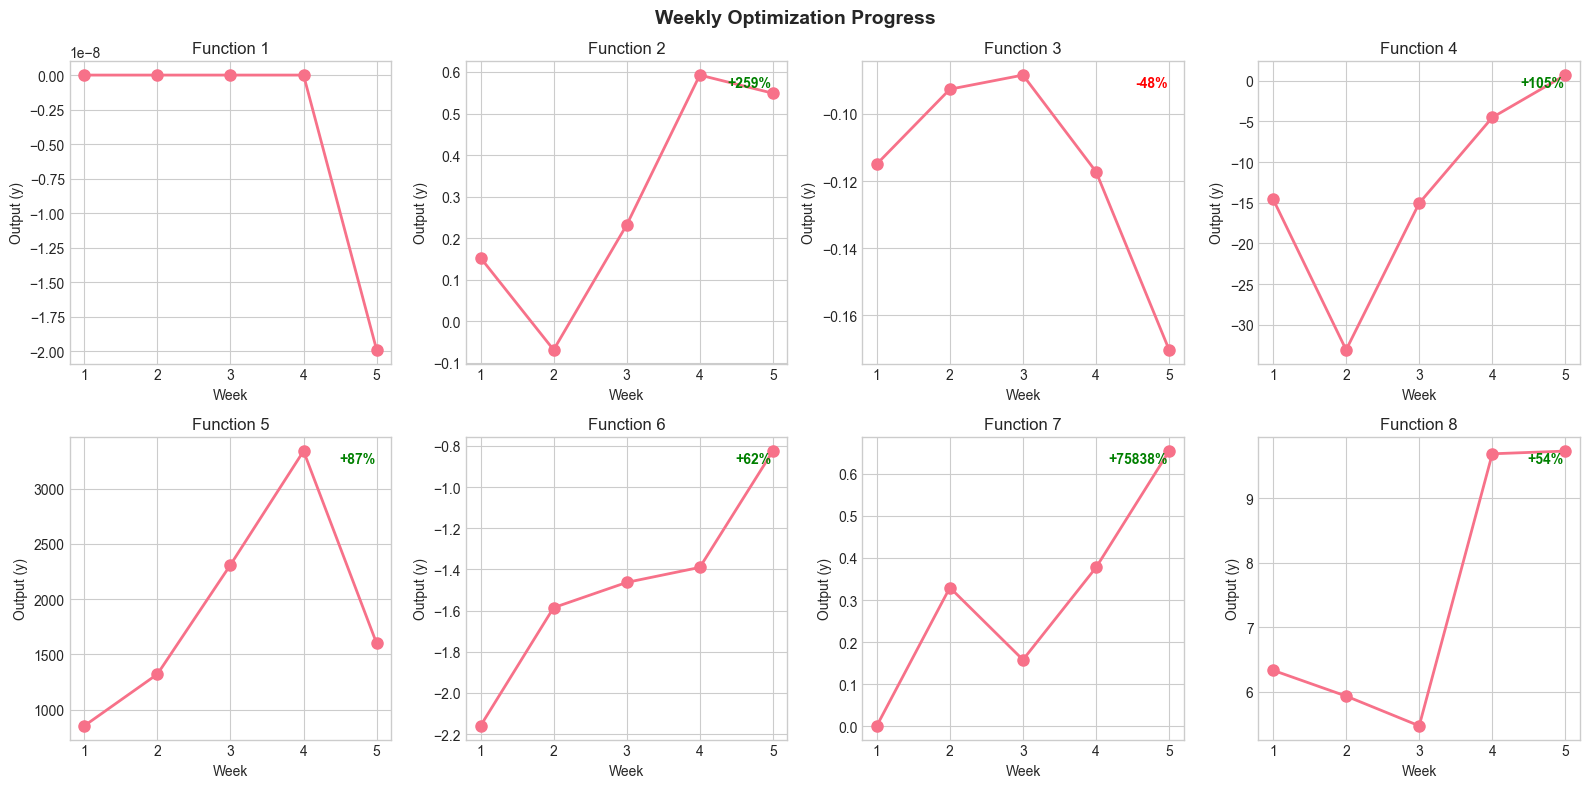

In [9]:
# Calculate cumulative best (running maximum)
cumulative_best = {}
for fid in range(1, 9):
    func_results = results_df[results_df['Function'] == fid].sort_values('Week')
    cumulative_best[fid] = func_results['y'].cummax().values

# Visualize progress for select functions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

weeks = sorted(weekly_data.keys())

for idx, fid in enumerate(range(1, 9)):
    ax = axes[idx]
    func_data = results_df[results_df['Function'] == fid].sort_values('Week')
    
    ax.plot(func_data['Week'], func_data['y'], 'o-', markersize=8, linewidth=2)
    ax.set_xlabel('Week')
    ax.set_ylabel('Output (y)')
    ax.set_title(f'Function {fid}')
    ax.set_xticks(weeks)
    
    # Add trend annotation (skip if values are too small for % to be meaningful)
    if len(func_data) > 1:
        first_val = func_data['y'].iloc[0]
        last_val = func_data['y'].iloc[-1]
        if first_val != 0 and abs(first_val) > 1e-10:
            change = (last_val - first_val) / abs(first_val) * 100
            ax.annotate(f'{change:+.0f}%', xy=(0.95, 0.95), xycoords='axes fraction',
                       ha='right', va='top', fontsize=10, fontweight='bold',
                       color='green' if change > 0 else 'red')

plt.suptitle('Weekly Optimization Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Function 5 Deep Dive (Success Case)

Function 5 showed the strongest improvement. Let's analyze why.

In [10]:
# Function 5 baseline analysis
f5_baseline = baseline_data[5]
print("Function 5 Baseline Data:")
print(f5_baseline.sort_values('y', ascending=False).head(10))

Function 5 Baseline Data:
          x1        x2        x3        x4            y
15  0.224189  0.846480  0.879484  0.878516  1088.859620
18  0.119879  0.862540  0.643331  0.849804   431.612757
14  0.438933  0.774092  0.378167  0.933696   355.806818
4   0.836478  0.193610  0.663893  0.785649   258.370525
9   0.463442  0.630025  0.107906  0.957644   233.223610
7   0.352356  0.322242  0.116979  0.473113   109.571876
13  0.511142  0.817957  0.728710  0.112354    79.729130
5   0.683432  0.118663  0.829046  0.567577    78.434389
0   0.191447  0.038193  0.607418  0.414584    64.443440
11  0.583973  0.147243  0.348097  0.428615    64.420147


In [11]:
# Correlation analysis for F5
f5_corr = f5_baseline.corr()['y'].drop('y').sort_values(ascending=False)
print("\nCorrelation of inputs with output (y):")
print(f5_corr)


Correlation of inputs with output (y):
x4    0.569877
x2    0.389340
x3    0.367304
x1   -0.284356
Name: y, dtype: float64


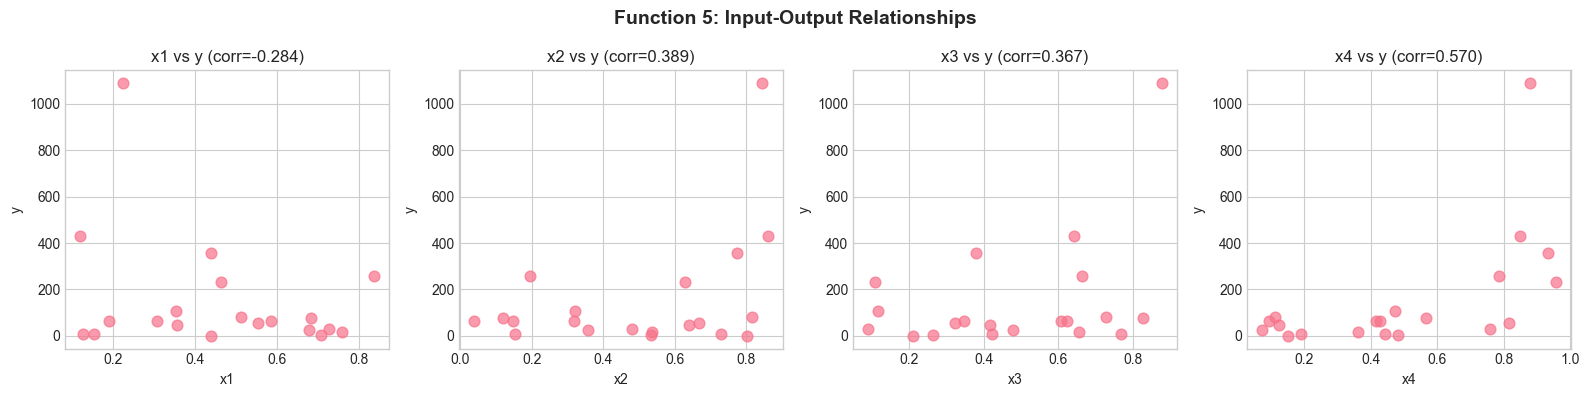

In [12]:
# Visualize F5 input-output relationships
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, col in enumerate(['x1', 'x2', 'x3', 'x4']):
    ax = axes[idx]
    ax.scatter(f5_baseline[col], f5_baseline['y'], alpha=0.7, s=60)
    ax.set_xlabel(col)
    ax.set_ylabel('y')
    ax.set_title(f'{col} vs y (corr={f5_corr[col]:.3f})')

plt.suptitle('Function 5: Input-Output Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insight for F5

The correlation analysis reveals:
- **x4** has strong positive correlation with output
- **x3** and **x2** also contribute positively
- **x1** has negative correlation (lower is better)

This explains why our queries evolved toward: `[low, high, high, high]` pattern.

In [13]:
# Show the F5 query evolution
f5_queries = results_df[results_df['Function'] == 5].sort_values('Week')

print("Function 5 Weekly Queries and Results:")
for week in sorted(weekly_data.keys()):
    week_data = weekly_data[week]
    f5_row = week_data[week_data['function_id'] == 5].iloc[0]
    query = [f5_row[f'x{i}'] for i in range(1, 5) if pd.notna(f5_row.get(f'x{i}', np.nan))]
    print(f"  Week {week}: {query} -> y = {f5_row['y']:.2f}")

Function 5 Weekly Queries and Results:
  Week 1: [np.float64(0.85), np.float64(0.85), np.float64(0.85), np.float64(0.15)] -> y = 854.55
  Week 2: [np.float64(0.25), np.float64(0.85), np.float64(0.9), np.float64(0.9)] -> y = 1321.76
  Week 3: [np.float64(0.2), np.float64(0.9), np.float64(0.95), np.float64(0.95)] -> y = 2309.86
  Week 4: [np.float64(0.15), np.float64(0.95), np.float64(0.98), np.float64(0.98)] -> y = 3338.75
  Week 5: [np.float64(0.001), np.float64(0.999), np.float64(0.999), np.float64(0.001)] -> y = 1599.96


### 7. Function 1 Analysis (Challenging Case)

Function 1 shows extremely small values, suggesting a very narrow peak or numerical challenges.

In [14]:
f1_baseline = baseline_data[1]
print("Function 1 Baseline Data:")
print(f1_baseline)

print(f"\nOutput range: {f1_baseline['y'].min():.2e} to {f1_baseline['y'].max():.2e}")
print(f"Most outputs are extremely close to zero (10^-40 to 10^-140 scale)")

Function 1 Baseline Data:
         x1        x2              y
0  0.319404  0.762959   1.322677e-79
1  0.574329  0.879898   1.033078e-46
2  0.731024  0.733000   7.710875e-16
3  0.840353  0.264732  3.341771e-124
4  0.650114  0.681526  -3.606063e-03
5  0.410437  0.147554  -2.159249e-54
6  0.312691  0.078723  -2.089093e-91
7  0.683418  0.861057   2.535001e-40
8  0.082507  0.403488   3.606771e-81
9  0.883890  0.582254   6.229856e-48

Output range: -3.61e-03 to 7.71e-16
Most outputs are extremely close to zero (10^-40 to 10^-140 scale)


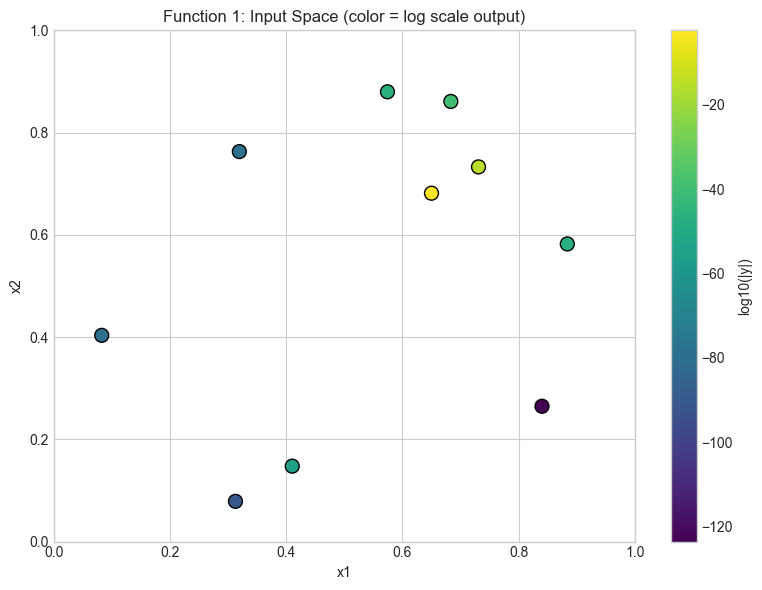

In [15]:
# 2D visualization for F1 (since it's 2D)
fig, ax = plt.subplots(figsize=(8, 6))

# Use log scale for color
log_y = np.log10(np.abs(f1_baseline['y']) + 1e-300)
scatter = ax.scatter(f1_baseline['x1'], f1_baseline['x2'], 
                     c=log_y, cmap='viridis', s=100, edgecolors='black')

plt.colorbar(scatter, label='log10(|y|)')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Function 1: Input Space (color = log scale output)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 8. Summary and Key Insights (based on baseline + W1-W5 data)

What we learned from data exploration:
1. Function 5 is the most learnable: Clear structure, strong correlations, consistent improvement
2. Function 1 is pathological: Near-zero values everywhere, likely has a very narrow optimum
3. Functions 3, 4, 6 are consistently negative**: May need to reframe as minimization
4. Higher-dimensional functions (7, 8) are harder to visualize but show moderate promise

### Strategy implications (based on early weeks — some of these changed later):

| Function Type | Strategy | Rationale |
|--------------|----------|----------|
| Structured (F2, F5) | EI (Expected Improvement) | Exploit known good regions |
| Noisy/Flat (F1, F3, F6, F7) | UCB (Upper Confidence Bound) | Explore to find any signal |
| Negative (F4) | UCB | Explore to find less negative values |
| High-dim (F8) | UCB | Explore the large space |

### Next steps:
- Implement Gaussian Process surrogate model (Notebook 02)
- Use GP to quantify uncertainty and guide acquisition functions
- Compare GP-based recommendations with our heuristic approach

In [16]:
# Final summary table
summary = []
for fid in range(1, 9):
    baseline = baseline_data[fid]
    weekly = results_df[results_df['Function'] == fid]
    
    summary.append({
        'Function': fid,
        'Dimensions': FUNCTION_DIMENSIONS[fid],
        'Baseline Samples': len(baseline),
        'Baseline Max': baseline['y'].max(),
        'Week 4 Result': weekly[weekly['Week'] == max(weekly['Week'])]['y'].values[0] if len(weekly) > 0 else None,
        'Strategy': classification[fid]['strategy'],
        'Type': classification[fid]['type']
    })

summary_df = pd.DataFrame(summary)
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))


FINAL SUMMARY
 Function  Dimensions  Baseline Samples  Baseline Max  Week 4 Result Strategy                Type
        1           2                10  7.710875e-16  -1.988830e-08      UCB     Extremely Noisy
        2           2                10  6.112052e-01   5.487662e-01       EI          Structured
        3           3                15 -3.483531e-02  -1.702649e-01      UCB          Flat/Noisy
        4           4                30 -4.025542e+00   6.958826e-01      UCB Negative Structured
        5           4                20  1.088860e+03   1.599958e+03       EI Strongly Structured
        6           5                20 -7.142650e-01  -8.253296e-01      UCB      Noisy Negative
        7           6                30  1.364968e+00   6.541262e-01      UCB          Low Signal
        8           8                40  9.598482e+00   9.729255e+00      UCB            Moderate


In [ ]:
# Weekly progress through W6 — re-run this cell to see the latest picture
# (code is unchanged from Section 5; outputs now include W6 data)

weekly_data_all = {}
for week in range(1, 14):
    path = WEEKLY_DIR / f'week_{week:02d}.csv'
    if path.exists():
        weekly_data_all[week] = pd.read_csv(path)

results_all = []
for week, df in weekly_data_all.items():
    for _, row in df.iterrows():
        results_all.append({
            'Week': week,
            'Function': int(row['function_id']),
            'y': get_y(row)
        })

results_all_df = pd.DataFrame(results_all)
pivot_all = results_all_df.pivot(index='Function', columns='Week', values='y')
print(f'Weekly results through Week {max(weekly_data_all.keys())}:')
print(pivot_all.to_string())

In [ ]:
# Best result per function across all weeks vs baseline
best_rows = []
for fid in range(1, 9):
    bl_best  = baseline_data[fid]['y'].max()
    wk_vals  = results_all_df[results_all_df['Function'] == fid]['y']
    wk_best  = wk_vals.max() if len(wk_vals) else None
    overall  = max(bl_best, wk_best) if wk_best is not None else bl_best
    src      = 'weekly' if wk_best and wk_best > bl_best else 'baseline'
    best_rows.append({
        'Function': fid,
        'Baseline Best': round(bl_best, 6),
        'Weekly Best':   round(wk_best, 6) if wk_best else None,
        'Overall Best':  round(overall, 6),
        'Source':        src,
    })

print(f'Best results per function (through W{max(weekly_data_all.keys())}):')
print(pd.DataFrame(best_rows).to_string(index=False))

---

### W6 Update — What Changed

Two findings from Week 6 contradict or extend the early analysis above.

**F5 — the [low, high, high, high] pattern was wrong.**
The baseline correlation analysis (Section 6) suggested x1 should be low and x2–x4 high. That drove W2–W4 queries and peaked at 3338. But W6 queried [0.999, 0.999, 0.999, 0.999] — x1 at 0.999, opposite of what the correlations suggested — and got 8585. More than double. The correlation from 10 baseline points was misleading. The true peak is at the full upper corner of the search space.

**F4 — no longer "consistently negative".**
Section 4 classified F4 as "Negative Structured" with UCB as the strategy. The surrogate model in W5 found a point returning 0.696 — the first positive result for this function. The model found a region the baseline data hadn't covered at all.